### The data used is from ChIP-seq (Chromatin Immunoprecipitation followed by sequencing) on DYRK1A

Aim of study: to map DYRK1A genome-wide binding sites and deliniate chromatin and gene expression regulation .

DYRK1A (Dual Specificity Tyrosine Phosphorylation-Regulated Kinase 1A)

DYRK1A regulates protein activity through phosphorylation and is crucial for nervous system development.
It is implicated in intellectual disability, developmental delays, mcrocephaly, speech impairment,
epilepsy and autistic features.

DYRK1A has unique ability to phosphorylate two different types of amino acid residues:
1. Tyrosine (Autophosphorylation) on a specific tyrosine residue (Tyr-321) within its activation loop.
2. Phosphorylated DYRK1A proceeds to substrate phosphorylation exclusively on serine or threonine residues.

DYRK1A substrates:
1. Specific isoforms of NFATc1, prevents ubiquitination.
2. NFAT (Nuclear Factor of Activated T-cells), promotes its export from nucleus
3. GLI1 to promote its nuclear import and activation in the Hedgehog pathway
4. CREB and STAT3 to modulate their transcriptional activity
5. splicing factors in alternative mRNA splicing
6. C-terminal domain (CTD) of RNA Polymerase II during transcription
7. H3 (which prevents transcriptional repression and activates pro-inflammatory cytokine genes.)
8. SWI/SNF chromatin remodeling complex and the silencer factor REST, leads to deregulating gene clusters essential for neuronal differentiation.

The original files downloaded from:
https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE155807

	
	
Di Vona C, Barba L, Ferrari R, de la Luna S.
Loss of the DYRK1A Protein Kinase Results in the Reduction in Ribosomal Protein Gene Expression,
Ribosome Mass and Reduced Translation.
Biomolecules 2023 Dec 25;14(1). PMID: 38254631

Files:

GSM4712413_DYRK1A-T98G_combo_peaks.txt.gz

(a combined set of binding sites derived from merging data across multiple conditions)

GSM4712413_DYRK1A-T98G_combo_poissP.bigwig

GSM4712414_DYRK1A-shControl-T98G_LB13_peaks.txt.gz

GSM4712414_DYRK1A-shControl-T98G_LB13_poissP.bigwig

GSM4712414_DYRK1A-shControl-T98G_LB13_peaks.txt.gz

GSM4712414_DYRK1A-shControl-T98G_LB13_poissP.bigwig

hg38.fa.gz (human reference genome)

### The logic of data utilisation:

reported peaks are strand - agnostic (genomic intervals where the specific DNA strand (forward + or reverse -) is unknown). So we will extract the DNA sequences from the forward strand first.

It looks like it is possible to train and simulteneously generate reverse strands and shifted regions, but my goal is to prepare the data locally and run ML algorithms locally.

Looking for DNA regions where DYRK1A assists in DNA binting.

| Sample Type | Case 1 | Case 2 | Case 3 | Case 4 | Case 5 | Case 6 (*) | Case 7 | Case 8 | **ML Label / Action** |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **DYRK1A ChIP-Seq** | + | + | + | - | - | - | + | + | *Experimental Sample* |
| **shControl** | - | + | + | - | + | - | + | - | *Off target control* |
| **shDYRK1A** | - | - | + | - | + | + | - | + | *Knockdown DYRK1A control* |
| **Conclusion** | **0** | **1** | **0** | **0** | **0** | **0** | **0** | **0** | *Final Label* |
| **Note** | Artifact | **True Positive** | Artifact | No Signal | Artifact | **Noise** | Artifact | Artifact | |

  



In [38]:
import pandas as pd

# Read the file (BED files usually have no header)
df = pd.read_csv("t98g_dyrk1a.bed", sep="\t", header=None)

# Enumerate rows
print(f"Total rows: {len(df)}")   

Total rows: 2117


### Project 1
### Data Preparation Plan for DYRK1A ChIP-seq ML Project 1

0.  **Start with BED files.** Use the peak coordinates from `DYRK1A_ChIP`, `shControl`, and `shDYRK1A`.
*For now I will not use BigWig files to extract scores for this classification task. The peak presence/absence is my primary signal.*

1.  **Define Labels using Controls:** Combine the three BED files.
    *   **Label 1 (Positive):** Peaks in `DYRK1A_ChIP` that are **absent** in `shDYRK1A` (true binding sites).
    *   **Label 0 (Negative):** Peaks in `DYRK1A_ChIP` that are **present** in `shDYRK1A` (non-specific noise/artifact).
    *   *Validation:* Ensure `shControl` is consistent (e.g., a true positive peak should be present in `shControl`).

2.  **Extract DNA Sequences:** For all peaks (both Label 1 and Label 0), extract the DNA sequence (e.g., ±100bp from the summit) from the reference genome.

3.  **Apply Reverse Complement Augmentation:** For every extracted sequence, generate its reverse complement. This doubles the dataset and ensures the model learns sequence motifs regardless of strand orientation. Assign the **same label** to the reverse complement.

4.  **Apply Shift Augmentation (Optional):** For robustness, extract sequences with small shifts (±10-20 bp) from the original peak summit. This teaches the model to find motifs even if the peak call is slightly off-center. Assign the **same label** to shifted versions.

5.  **Calculate GC Content (For Model Features, Not Labeling):** Compute the GC content for each sequence. This will be an **additional input feature** for the ML model to help it account for background sequence bias. This does not define labels.

6.  **The final dataset** is a list of DNA sequences (original + reverse complement + shifts) with their corresponding labels (0 or 1) and optional features (GC content). This is ready for one-hot encoding and model training.

7. **Separate Features (X) and Targets (Y)**
Split the final processed table into two distinct arrays:

**X (Features):** The DNA sequences (converted to One-Hot Encoded matrices).
Shape: (Number_of_Samples, 4, Sequence_Length)
Content: The A/C/G/T matrices for every peak (original + reverse complement + shifts).

**Y (Targets):** The Labels or Scores.
Shape: (Number_of_Samples,)
Content:
For Classification: The binary labels (1 for true binding, 0 for noise).



### Project 2
### Data Preparation Plan for DYRK1A ChIP-seq Regression ML Project

0.  **Start with BED and BigWig files.** Use the peak coordinates from `DYRK1A_ChIP.bed` and the signal intensity from `DYRK1A_ChIP.bw`. Extract the **maximum** or **mean** score for each peak using `pyBigWig` or `bigWigAverageOverBed`.

1.  **Define Intensity Scores using Controls:** For every peak in `DYRK1A_ChIP.bed`:
    *   **If the peak is absent in `shDYRK1A`:** Keep the original intensity score (e.g., 12.5). This is a true binding site.
    *   **If the peak is present in `shDYRK1A`:** Set its intensity score to **0**. This signal is noise/artifact.
    *   *Validation:* Ensure `shControl` is consistent (e.g., a true peak should be present in `shControl`).

2.  **Extract DNA Sequences:** For all peaks, extract the DNA sequence (e.g., ±100bp from the summit) from the reference genome.

3.  **Apply Reverse Complement Augmentation:** For every sequence, generate its reverse complement. Assign it the **same intensity score** as the original. This doubles your dataset.

4.  **Apply Shift Augmentation (Optional):** Extract sequences with small shifts (±10-20 bp) from the summit. Assign the **same intensity score** to shifted versions.

5.  **Calculate GC Content (Optional Feature):** Compute the GC content for each sequence. You can include this as an **additional input feature** to help the model.

6.  **Separate Features (X) and Targets (Y):**
    *   **X (Features):** The **DNA sequences** (one-hot encoded) and optional features (e.g., GC content).
    *   **Y (Targets):** The **continuous intensity scores** (normalized, e.g., scaled to 0-1).

7.  **Data is Ready:** Your final dataset (X, Y) is ready for a regression model with a `Linear` output layer and `Mean Squared Error` loss.   

### THEORY
### 1. Convolutional Neural Networks (CNN)
*   **Best For:** Both **Classification** and **Regression**. This is the industry standard for DNA sequence analysis.
*   **Why:** It automatically scans your sequence to find **motifs** (patterns) regardless of their position.
*   **Python Library:** `TensorFlow` (Keras) or `PyTorch`.
*   **How to use:**
    *   **Classification:** Final layer uses `sigmoid` activation; Loss function is `binary_crossentropy`.
    *   **Regression:** Final layer uses `linear` activation; Loss function is `mean_squared_error` (MSE).

### 2. Random Forest (RF)
*   **Best For:** **Classification** (and Regression) as a **baseline**.
*   **Why:** It is robust and easy to interpret. It does not use raw sequences directly; you must first convert your DNA into **k-mer counts** (e.g., how many times "ATGC" appears).
*   **Python Library:** `scikit-learn` (`RandomForestClassifier` or `RandomForestRegressor`).
*   **Comparison:** Use this to see if a complex Deep Learning model (CNN) is actually necessary. If RF performs nearly as well, stick with RF.

### 3. Hybrid CNN-RNN (LSTM/GRU)
*   **Best For:** Advanced **Classification** or **Regression** if you suspect long-range dependencies.
*   **Why:** The CNN finds local motifs, and the RNN (Recurrent Neural Network) learns the **order** or "grammar" of those motifs (e.g., Motif A usually appears 50bp before Motif B).
*   **Python Library:** `TensorFlow` (Keras) (`LSTM` or `GRU` layers).
*   **Note:** This is more complex and slower to train. Only use this if the standard CNN does not perform well enough.

### 4. Support Vector Machine (SVM)
*   **Best For:** **Classification** on smaller datasets.
*   **Why:** Effective at finding boundaries between classes in high-dimensional space (like k-mer counts).
*   **Python Library:** `scikit-learn` (`SVC`).
*   **Note:** Can be very slow on large genomic datasets compared to Random Forest or CNN.

### Recommended Comparison Plan
1.  **Baseline:** Train a **Random Forest** on k-mer counts. Record the accuracy (or MSE).
2.  **Primary Model:** Train a **1D CNN** on one-hot encoded sequences. Record the accuracy.
3.  **Advanced (Optional):** If the CNN is good but not perfect, try adding an **LSTM** layer after the CNN to see if it captures long-range patterns.

**Summary:** Start with **CNN** for your main results and **Random Forest** as a simple comparison.

In [21]:
'''%%bash
# Extract GSM4712414 (shControl) and rename to shControl.bed
gunzip -c GSM4712414_DYRK1A-shControl-T98G_LB13_peaks.txt.gz > shControl.bed

# Extract GSM4712415 (shDYRK1A) and rename to shDYRK1A.bed
gunzip -c GSM4712415_DYRK1A-shDYRK1A-T98G_LB15_peaks.txt.gz > shDYRK1A.bed'''

'%%bash\n# Extract GSM4712414 (shControl) and rename to shControl.bed\ngunzip -c GSM4712414_DYRK1A-shControl-T98G_LB13_peaks.txt.gz > shControl.bed\n\n# Extract GSM4712415 (shDYRK1A) and rename to shDYRK1A.bed\ngunzip -c GSM4712415_DYRK1A-shDYRK1A-T98G_LB15_peaks.txt.gz > shDYRK1A.bed'

In [22]:
'''%%bash
# Rename shControl
mv GSM4712414_DYRK1A-shControl-T98G_LB13_poissP.bigwig shControl.bw

# Rename shDYRK1A
mv GSM4712415_DYRK1A-shDYRK1A-T98G_poissP.bigwig shDYRK1A.bw

# Rename ChIP-seq DYRK1A bigwig
mv t98g_signal.bigwig t98g_dyrk1a.bw'''

'%%bash\n# Rename shControl\nmv GSM4712414_DYRK1A-shControl-T98G_LB13_poissP.bigwig shControl.bw\n\n# Rename shDYRK1A\nmv GSM4712415_DYRK1A-shDYRK1A-T98G_poissP.bigwig shDYRK1A.bw\n\n# Rename ChIP-seq DYRK1A bigwig\nmv t98g_signal.bigwig t98g_dyrk1a.bw'

In [ ]:
# ===================================
# Opens BigWig files to extract and label signal scores
# for 577 true peaks and 1,540 noise peaks, then saves the
# combined dataset of 2,117 labeled entries to a CSV file.
# ===================================

import pyBigWig
import pandas as pd
import pybedtools

# 1. Define Paths
chip_bed = "t98g_dyrk1a.bed"
chip_bw = "t98g_dyrk1a.bw"
sh_control_bed = "shControl.bed"
sh_dyrk1a_bed = "shDYRK1A.bed"

# 2. Load Peaks
peaks = pybedtools.BedTool(chip_bed)
sh_control_peaks = pybedtools.BedTool(sh_control_bed)
sh_dyrk1a_peaks = pybedtools.BedTool(sh_dyrk1a_bed)

# 3. Define Groups:
# Group A: Consistent (ChIP AND shControl)
consistent_peaks = peaks.intersect(sh_control_peaks, u=True)
# Group B: True Signal (Consistent BUT NOT in shDYRK1A)
true_signal_peaks = consistent_peaks.intersect(sh_dyrk1a_peaks, v=True)
# Group C: Noise (Everything else)
noise_peaks = peaks.intersect(true_signal_peaks, v=True)

# 4. Extract Scores (for ALL peaks)
print("Opening BigWig files...")
bw_chip = pyBigWig.open(chip_bw)

def extract_mean_scores(bw, bed_iter):
    scores = []
    for peak in bed_iter:
        val = bw.stats(peak.chrom, peak.start, peak.end, type='mean')
        # If BigWig has no coverage, return 0.0, otherwise return the mean
        scores.append(val[0] if val and val[0] is not None else 0.0)
    return scores

print("Extracting scores for True Signal peaks")
true_scores = extract_mean_scores(bw_chip, true_signal_peaks)

print("Extracting scores for Noise peaks")
noise_scores = extract_mean_scores(bw_chip, noise_peaks)

# 5. Build DataFrame with BOTH Score and Label
all_peaks_data = []

# Add True Signals
for peak, score in zip(true_signal_peaks, true_scores):
    all_peaks_data.append({
        'chrom': peak.chrom,
        'start': peak.start,
        'end': peak.end,
        'sequence': '', # Placeholder to be filled later
        'final_score': score,      # Continuous value for Regression
        'label': 1,                # Binary label (1=True) for Classification
        'type': 'True_Signal'
    })

# Add Noise Peaks
for peak, score in zip(noise_peaks, noise_scores):
    all_peaks_data.append({
        'chrom': peak.chrom,
        'start': peak.start,
        'end': peak.end,
        'sequence': '', # Placeholder
        'final_score': score,      # Continuous value (might be low, but real)
        'label': 0,                # Binary label (0=False)
        'type': 'Noise'
    })

# 6. Saving Results
df = pd.DataFrame(all_peaks_data)
output_file = "dyrk1a_labeled_scores_corrected.csv"
df.to_csv(output_file, index=False)

print(f"\n✅ Done! Saved {len(df)} peaks to {output_file}")
print(f"True Signals: {len(true_scores)} | Noise: {len(noise_scores)}")
print(f"Score Range: {df['final_score'].min():.4f} to {df['final_score'].max():.4f}")
print(f"Unique Labels: {df['label'].unique()}")

bw_chip.close()   

Opening BigWig files...
Extracting scores for True Signal peaks
Extracting scores for Noise peaks

✅ Done! Saved 2117 peaks to dyrk1a_labeled_scores_corrected.csv
True Signals: 577 | Noise: 1540
Score Range: 8.0056 to 16.0000
Unique Labels: [1 0]


In [2]:
import pandas as pd

df = pd.read_csv("dyrk1a_labeled_scores_corrected.csv")
print(df.columns)
print(df.head(2))   

Index(['chrom', 'start', 'end', 'sequence', 'final_score', 'label', 'type'], dtype='object')
  chrom      start        end  sequence  final_score  label         type
0  chr5  181204901  181205050       NaN    13.883303      1  True_Signal
1  chr5  181204501  181204650       NaN    12.685785      1  True_Signal


The ratio is roughly 1:2.7 (577 vs 1540), which looks like imbalance case. The danger is a machine learning model might become biased toward predicting "0" (noise) simply because it's more common. Need to ensure the model uses class weights or stratified sampling to handle the imbalance.

In [ ]:
# ============================
# checking for chromosomes names match
# ============================

import pandas as pd
from pyfaidx import Fasta

# 1. Load Genome Headers
print(">>> Genome File (hg38.fa) Headers:")
genome = Fasta("hg38.fa")
print(list(genome.keys())[:5])  # Shows first 5 chromosome names in genome

# 2. Load and Display CSV
print("\n>>> CSV File (First 5 Rows):")
df_csv = pd.read_csv("dyrk1a_labeled_scores_corrected.csv")
print(df_csv[['chrom', 'start', 'end']].head())
print(f"Unique Chromosomes in CSV: {df_csv['chrom'].unique()[:5]}")

# 3. Load and Display BED (if applicable)
# Replace 'your_file.bed' with your actual BED filename
try:
    print("\n>>> BED File (First 5 Rows):")
    df_bed = pd.read_csv(chip_bed, sep='\t', header=None)

    # Standard BED columns: 0=chrom, 1=start, 2=end
    print(df_bed.iloc[:, [0, 1, 2]].head())
    print(f"Unique Chromosomes in BED: {df_bed.iloc[:, 0].unique()[:5]}")
except FileNotFoundError:
    print("\n>>> BED file not found. Skipping BED check.")

# 4. Comparison Check
csv_chroms = set(df_csv['chrom'].astype(str).unique())
genome_chroms = set(genome.keys())

print("\n>>> Discrepancy Check:")
missing_in_genome = csv_chroms - genome_chroms
if missing_in_genome:
    print(f"⚠️  Chromosomes in CSV but NOT in Genome: {list(missing_in_genome)[:5]}")
    print("   → Likely cause: 'chr' prefix mismatch (e.g., CSV has 'chr1', Genome has '1').")
else:
    print("✅ All CSV chromosomes found in Genome.")   

>>> Genome File (hg38.fa) Headers:
['chr1', 'chr10', 'chr11', 'chr11_KI270721v1_random', 'chr12']

>>> CSV File (First 5 Rows):
   chrom      start        end
0   chr5  181204901  181205050
1   chr5  181204501  181204650
2   chrX   53683351   53683450
3   chr1  183471201  183471300
4  chr14  102314251  102314350
Unique Chromosomes in CSV: ['chr5' 'chrX' 'chr1' 'chr14' 'chr2']

>>> BED File (First 5 Rows):
      0          1          2
0  chrM      13651      13850
1  chrM      14801      16500
2  chrM      12751      13100
3  chrM       2701       2850
4  chr5  181188251  181189500
Unique Chromosomes in BED: ['chrM' 'chr5' 'chr17' 'chr1' 'chr8']

>>> Discrepancy Check:
✅ All CSV chromosomes found in Genome.


In [6]:
# =======================================
# Enumerate peaks too close to chromosome ends AND missing chromosomes
# ======================================

import pandas as pd
from pyfaidx import Fasta

# 1. Load Data and Genome
print(">>> Loading data and genome...")
df = pd.read_csv("dyrk1a_labeled_scores_corrected.csv")
genome = Fasta("hg38.fa")

# 2. Parameters
window_size = 100
total_rows = len(df)

# 3. Identify Problematic Peaks
print(">>> Scanning for errors...")
problematic_peaks = []
missing_chrom_peaks = []  # Specific list for missing chromosomes
boundary_overflow_peaks = [] # Specific list for boundary issues

count_missing_chrom = 0
count_boundary_overflow = 0

for i, row in df.iterrows():
    chrom = str(row['chrom']).strip()
    start = int(row['start'])
    end = int(row['end'])
    
    # Check 1: Chromosome Existence
    if chrom not in genome.keys():
        count_missing_chrom += 1
        entry = {
            'index': i,
            'reason': 'Chromosome not found',
            'chrom': chrom,
            'start': start,
            'end': end,
            'label': row['label']
        }
        problematic_peaks.append(entry)
        missing_chrom_peaks.append(entry)
        continue

    chrom_len = len(genome[chrom])
    center = (start + end) // 2
    s = max(0, center - window_size)
    e = center + window_size + 1
    
    # Check 2: Boundary Overflow
    if e > chrom_len:
        count_boundary_overflow += 1
        entry = {
            'index': i,
            'reason': 'End of chromosome overflow',
            'chrom': chrom,
            'start': start,
            'end': end,
            'center': center,
            'chrom_end': chrom_len,
            'missing_bases': e - chrom_len,
            'label': row['label']
        }
        problematic_peaks.append(entry)
        boundary_overflow_peaks.append(entry)

# 4. Report Statistics
count_problem = len(problematic_peaks)
percent_problem = (count_problem / total_rows) * 100

print(f"\n>>> Results:")
print(f"Total Peaks: {total_rows}")
print(f"Total Problematic Peaks: {count_problem} ({percent_problem:.2f}%)")
print(f"  - Missing Chromosomes: {count_missing_chrom}")
print(f"  - Boundary Overflows:  {count_boundary_overflow}")
print(f"Valid Peaks (will remain): {total_rows - count_problem}")

# Breakdown by Label (True Signal vs Noise)
if problematic_peaks:
    df_prob = pd.DataFrame(problematic_peaks)
    label_counts = df_prob['label'].value_counts()
    print(f"\nBreakdown by Label (Total Lost):")
    print(f"  True Signals (1) lost: {label_counts.get(1, 0)}")
    print(f"  Noise (0) lost:        {label_counts.get(0, 0)}")

# 5. Save Detailed Lists
if count_missing_chrom > 0:
    pd.DataFrame(missing_chrom_peaks).to_csv("peaks_removed_missing_chrom.csv", index=False)
    print(f"\n✅ List of missing chromosome errors saved to: peaks_removed_missing_chrom.csv")

if count_boundary_overflow > 0:
    pd.DataFrame(boundary_overflow_peaks).to_csv("peaks_removed_boundary.csv", index=False)
    print(f"✅ List of boundary overflow errors saved to: peaks_removed_boundary.csv")

if count_problem == 0:
    print("\n✅ No problematic peaks found. All sequences can be extracted fully.")   

>>> Loading data and genome...
>>> Scanning for errors...

>>> Results:
Total Peaks: 2117
Total Problematic Peaks: 0 (0.00%)
  - Missing Chromosomes: 0
  - Boundary Overflows:  0
Valid Peaks (will remain): 2117

✅ No problematic peaks found. All sequences can be extracted fully.


In [7]:
# =======================================
# checking CSV file to find rows with invalid coordinates that would
# cause pyfaidx to fail or return short sequences
# ======================================

import pandas as pd

df = pd.read_csv("dyrk1a_labeled_scores_corrected.csv")
invalid_rows = []

for i, row in df.iterrows():
    start = int(row['start'])
    end = int(row['end'])
    
    # Check for logical errors in coordinates
    if start < 0:
        invalid_rows.append((i, "Start < 0", start, end))
    if end <= start:
        invalid_rows.append((i, "End <= Start", start, end))
    if start > end:
        invalid_rows.append((i, "Start > End", start, end))

print(f"Total rows: {len(df)}")
print(f"Rows with invalid coordinates: {len(invalid_rows)}")
if invalid_rows:
    print("First 5 invalid rows:")
    for item in invalid_rows[:5]:
        print(item)   

Total rows: 2117
Rows with invalid coordinates: 0


Chromosome names match (0 missing).
Coordinates are valid (no negative starts, start < end).
Boundary overflows are 0 (based on your latest enumeration).

In [11]:
import pandas as pd
import numpy as np

# 1. Load Data
input_file = "dyrk1a_labeled_scores_corrected.csv"
df = pd.read_csv(input_file)

# 2. Calculate Width
df['width'] = df['end'] - df['start']

# 3. Define Window Size
WINDOW_SIZE = 201  # ±100bp from center

# 4. Analyze by Label
labels = {1: "Real Peaks (Label 1)", 0: "False/Noise Peaks (Label 0)"}

print(f"--- Analysis for {WINDOW_SIZE}bp Window ---\n")

for label_val, label_name in labels.items():
    subset = df[df['label'] == label_val]
    total = len(subset)
    
    if total == 0:
        print(f"{label_name}: No samples found.")
        continue

    # Count how many are WIDER than the window (will be shortened/truncated)
    shortened_count = len(subset[subset['width'] > WINDOW_SIZE])
    percent_shortened = (shortened_count / total) * 100
    
    # Count how many are NARROWER (will be padded/expanded)
    expanded_count = len(subset[subset['width'] <= WINDOW_SIZE])
    
    print(f"{label_name}:")
    print(f"  Total Count: {total}")
    print(f"  Median Width: {subset['width'].median():.1f} bp")
    print(f"  > {WINDOW_SIZE}bp (Will be SHORTENED): {shortened_count} ({percent_shortened:.1f}%)")
    print(f"  ≤ {WINDOW_SIZE}bp (Will be EXPANDED): {expanded_count} ({100-percent_shortened:.1f}%)")
    print(f"  Max Width: {subset['width'].max()} bp")
    print("-" * 40)

# 5. Detailed Text Histogram (Side-by-Side comparison optional, here sequential)
def print_text_histogram_group(data, title, bins=15, width=50):
    if len(data) == 0: return
    counts, bin_edges = np.histogram(data, bins=bins)
    max_count = counts.max()
    print(f"\n{title} (n={len(data)})")
    for i, count in enumerate(counts):
        bar_len = int((count / max_count) * width) if max_count > 0 else 0
        bar = '#' * bar_len
        label = f"{bin_edges[i]:.0f}-{bin_edges[i+1]:.0f}"
        # Mark the window cutoff visually
        marker = " <-- WINDOW CUTOFF" if bin_edges[i] <= WINDOW_SIZE and bin_edges[i+1] > WINDOW_SIZE else ""
        print(f"{label:>8} | {bar:<{width}} ({count}){marker}")

# Print histograms for both groups
print_text_histogram_group(df[df['label']==1]['width'], "Width Distribution: REAL PEAKS")
print_text_histogram_group(df[df['label']==0]['width'], "Width Distribution: FALSE PEAKS")   

--- Analysis for 201bp Window ---

Real Peaks (Label 1):
  Total Count: 577
  Median Width: 49.0 bp
  > 201bp (Will be SHORTENED): 8 (1.4%)
  ≤ 201bp (Will be EXPANDED): 569 (98.6%)
  Max Width: 549 bp
----------------------------------------
False/Noise Peaks (Label 0):
  Total Count: 1540
  Median Width: 199.0 bp
  > 201bp (Will be SHORTENED): 677 (44.0%)
  ≤ 201bp (Will be EXPANDED): 863 (56.0%)
  Max Width: 2449 bp
----------------------------------------

Width Distribution: REAL PEAKS (n=577)
   49-82 | ################################################## (312)
  82-116 | ##############################                     (192)
 116-149 |                                                    (0)
 149-182 | ########                                           (54)
 182-216 | #                                                  (11) <-- WINDOW CUTOFF
 216-249 |                                                    (0)
 249-282 |                                                    (4)
 282-316 |

✅ Plot saved as 'peak_width_distribution.png'


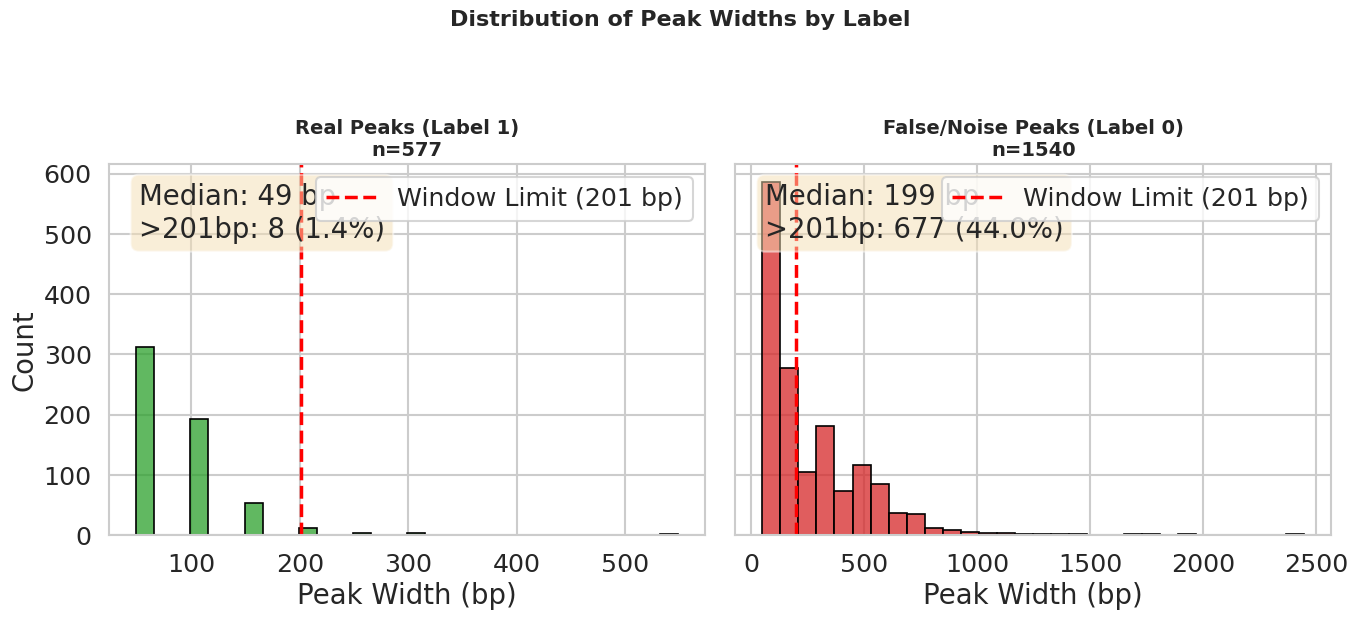

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Style for Presentation
sns.set_theme(style="whitegrid", context="talk", font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

# 1. Load Data
input_file = "dyrk1a_labeled_scores_corrected.csv"
df = pd.read_csv(input_file)
df['width'] = df['end'] - df['start']

# Separate groups
real_peaks = df[df['label'] == 1]['width']
false_peaks = df[df['label'] == 0]['width']

# Define Window Cutoff
WINDOW_CUTOFF = 201

# 2. Create Plot
fig, axes = plt.subplots(1, 2, sharey=True)

# --- Panel A: Real Peaks ---
sns.histplot(real_peaks, bins=30, color='#2ca02c', edgecolor='black', linewidth=1.2, ax=axes[0])
axes[0].axvline(WINDOW_CUTOFF, color='red', linestyle='--', linewidth=2.5, label=f'Window Limit ({WINDOW_CUTOFF} bp)')
axes[0].set_title(f'Real Peaks (Label 1)\nn={len(real_peaks)}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Peak Width (bp)')
axes[0].set_ylabel('Count')
axes[0].legend(loc='upper right')

# Add stats text
stats_text = f"Median: {real_peaks.median():.0f} bp\n>201bp: {len(real_peaks[real_peaks > WINDOW_CUTOFF])} ({len(real_peaks[real_peaks > WINDOW_CUTOFF])/len(real_peaks)*100:.1f}%)"
axes[0].text(0.05, 0.95, stats_text, transform=axes[0].transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# --- Panel B: False/Noise Peaks ---
sns.histplot(false_peaks, bins=30, color='#d62728', edgecolor='black', linewidth=1.2, ax=axes[1])
axes[1].axvline(WINDOW_CUTOFF, color='red', linestyle='--', linewidth=2.5, label=f'Window Limit ({WINDOW_CUTOFF} bp)')
axes[1].set_title(f'False/Noise Peaks (Label 0)\nn={len(false_peaks)}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Peak Width (bp)')
axes[1].set_ylabel('') # Hide y-label on second plot for cleanliness
axes[1].legend(loc='upper right')

# Add stats text
stats_text_false = f"Median: {false_peaks.median():.0f} bp\n>201bp: {len(false_peaks[false_peaks > WINDOW_CUTOFF])} ({len(false_peaks[false_peaks > WINDOW_CUTOFF])/len(false_peaks)*100:.1f}%)"
axes[1].text(0.05, 0.95, stats_text_false, transform=axes[1].transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Distribution of Peak Widths by Label', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()

# 3. Save and Show
output_image = "peak_width_distribution.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"✅ Plot saved as '{output_image}'")
plt.show()   

Step 2.  
**Extract DNA Sequences:** For all peaks, extract the DNA sequence (e.g., ±100bp from the summit) from the reference genome.

Why not to use native ChIP-seq peaks? They have variable lengths. Feeding variable lengths in the the matrix multiplication in the Convolutional layers would fail mathematically.

The model architecture expects an input tensor of shape (N, length, 4), where length is the length of DNA sequences we feed into CNN. It can be different, but there is a login in deciding how long.

The Summit: The "peak" in a BED file often spans a broad region (e.g., 300bp) where the protein might be bound. The summit (center) is the single base pair with the highest signal intensity—the most likely exact binding site.
The Motif: Transcription factor binding motifs are typically 6–20bp long.
The Context: By taking ±100bp (201bp total), you capture:
The core motif at the center.
The immediate flanking regions (which influence binding affinity via GC content or secondary structures).
Enough background to let the CNN learn what "non-binding" sequence looks like within the window.





In [9]:
# =======================================
# Step 1: Extract & Split into Two Files
# ======================================
import pandas as pd
from pyfaidx import Fasta

# 1. Load Data
print(">>> Loading data...")
input_file = "dyrk1a_labeled_scores_corrected.csv"
df = pd.read_csv(input_file)
genome = Fasta("hg38.fa", rebuild=True)
window_size = 100
target_len = 2 * window_size + 1  # 201

# Output filenames
file_with_dna = "dyrk1a_labeled_scores_corrected_DNA.csv"
file_no_dna = "dyrk1a_labeled_scores_corrected_NO_DNA.csv"

# Lists to hold split data
rows_with_dna = []
rows_without_dna = []

print(">>> Extracting sequences...")
for i, row in df.iterrows():
    try:
        chrom = str(row['chrom']).strip()
        start, end = int(row['start']), int(row['end'])
        
        # Check 1: Chromosome Exists
        if chrom not in genome.keys():
            rows_without_dna.append({
                **row.to_dict(), 
                'reason': 'Chromosome not found'
            })
            continue

        chrom_len = len(genome[chrom])
        center = (start + end) // 2
        s, e = max(0, center - window_size), center + window_size + 1
        
        # Check 2: Boundary Overflow
        if e > chrom_len:
            rows_without_dna.append({
                **row.to_dict(), 
                'reason': 'Boundary overflow'
            })
            continue

        # Check 3: Extract
        seq = str(genome[chrom][s:e].seq.upper())
        
        if len(seq) != target_len:
            rows_without_dna.append({
                **row.to_dict(), 
                'reason': 'Wrong length'
            })
            continue
            
        # Success: Add sequence to row
        row_dict = row.to_dict()
        row_dict['sequence'] = seq
        rows_with_dna.append(row_dict)

    except Exception as ex:
        rows_without_dna.append({
            **row.to_dict(), 
            'reason': f'Error: {str(ex)}'
        })

# 4. Save Two Files
# File 1: Successful Extractions
if rows_with_dna:
    df_dna = pd.DataFrame(rows_with_dna)
    df_dna.to_csv(file_with_dna, index=False)
    print(f"\n✅ Saved {len(df_dna)} rows with DNA to: {file_with_dna}")
else:
    print(f"\n⚠️  No sequences extracted successfully.")

# File 2: Failed Extractions
if rows_without_dna:
    df_no_dna = pd.DataFrame(rows_without_dna)
    df_no_dna.to_csv(file_no_dna, index=False)
    print(f"⚠️  Saved {len(df_no_dna)} failed rows to: {file_no_dna}")
    print(f"   Reasons: {df_no_dna['reason'].value_counts().to_dict()}")
else:
    print(f"✅ All peaks extracted successfully (No failed file created).")

print("\n>>> Step 1 Complete.")   

>>> Loading data...
>>> Extracting sequences...

✅ Saved 2117 rows with DNA to: dyrk1a_labeled_scores_corrected_DNA.csv
✅ All peaks extracted successfully (No failed file created).

>>> Step 1 Complete.


In [8]:
# =======================================
# Genomic Sequence Processing Pipeline
# ======================================
import pandas as pd
from pyfaidx import Fasta
import numpy as np

# 1. Load Data
df = pd.read_csv("dyrk1a_labeled_scores_corrected.csv")
genome = Fasta("hg38.fa", rebuild=True)
window_size = 100

# 2. Extract DNA Sequences
def extract_sequence(row):
    chrom, start, end = row['chrom'], int(row['start']), int(row['end'])
    center = (start + end) // 2
    s, e = max(0, center - window_size), center + window_size + 1
    if chrom in genome.keys() and e <= len(genome[chrom]):
        return str(genome[chrom][s:e].seq.upper())
    return None

print(">>> Extracting sequences...")
df['sequence'] = df.apply(extract_sequence, axis=1)
df = df.dropna(subset=['sequence'])  # Remove rows where extraction failed

# 3. Apply Reverse Complement Augmentation
print(">>> Applying reverse complement augmentation...")
def reverse_complement(seq):
    complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
    return ''.join(complement[base] for base in reversed(seq))

rc_rows = df.copy()
rc_rows['sequence'] = rc_rows['sequence'].apply(reverse_complement)
rc_rows['augmentation'] = 'reverse_complement'
df['augmentation'] = 'original'
df = pd.concat([df, rc_rows], ignore_index=True)

# 4. Apply Shift Augmentation (±20 bp)
print(">>> Applying shift augmentation...")
shifted_dfs = [df]
for shift in [-20, 20]:
    shifted_df = df[df['augmentation'] == 'original'].copy()
    # Re-extract sequence with shift
    shifted_df['start'] += shift
    shifted_df['end'] += shift
    shifted_df['sequence'] = shifted_df.apply(extract_sequence, axis=1)
    shifted_df = shifted_df.dropna(subset=['sequence'])
    shifted_df['augmentation'] = f'shift_{shift}'
    shifted_dfs.append(shifted_df)
df = pd.concat(shifted_dfs, ignore_index=True)

# 5. Calculate GC Content
print(">>> Calculating GC content...")
df['gc_content'] = df['sequence'].apply(
    lambda seq: (seq.count('G') + seq.count('C')) / len(seq) * 100
)

# Save Result
output_file = "dyrk1a_augmented_sequences_corrected.csv"
df.to_csv(output_file, index=False)
print(f"\n✅ Done! Saved {len(df)} sequences to {output_file}")   

>>> Extracting sequences...
>>> Applying reverse complement augmentation...


KeyError: 'N'

In [26]:
import pandas as pd

df = pd.read_csv("raw_sequences.csv")
print(df.columns)
print(df.head(2))   

Index(['chrom', 'start', 'end', 'final_score', 'type', 'sequence'], dtype='object')
  chrom      start        end           final_score         type  \
0  chr5  181204901  181205050  [13.883302899815092]  True_Signal   
1  chr5  181204501  181204650  [12.685784749536706]  True_Signal   

                                            sequence  
0  GACAGGGCAGTGGGAAGGGGGGCGCGCGGGTGGCGGCCCCAACAGA...  
1  GGCTCACCCGGGCCTCCTGATCGACAGGCTGTTCTCTGCACCCCGT...  


In [27]:
# ====================================
# The script takes raw_sequences.csv, creates Reverse Complements,
# generates Shifted versions (±20 bp), saving everything to a new CSV file.
# ==================================

import pandas as pd
import numpy as np
import random
import sys

# --- Configuration ---
INPUT_FILE = "raw_sequences.csv"
OUTPUT_FILE = "augmented_sequences.csv"
SHIFT_RANGE = 20  # Shift between -20 and +20 bp
PAD_CHAR = 'N'

print(f">>> Starting Data Augmentation...")
print(f"    Input: {INPUT_FILE}")
print(f"    Output: {OUTPUT_FILE}")

# 1. Load Data
try:
    df = pd.read_csv(INPUT_FILE)
    if 'sequence' not in df.columns:
        print("ERROR: 'sequence' column not found. Please run the extraction script first.")
        sys.exit()
    print(f"    Loaded {len(df)} original sequences.")
except Exception as e:
    print(f"ERROR loading file: {e}")
    sys.exit()

# 2. Define Helper Functions
complement_map = str.maketrans("ACGTN", "TGCAN")

def reverse_complement(seq):
    """Returns the reverse complement of a DNA sequence."""
    return seq.translate(complement_map)[::-1]

def shift_sequence(seq, shift_amount):
    """
    Shifts the sequence by shift_amount.
    Positive shift = move window right (crop start, pad end).
    Negative shift = move window left (pad start, crop end).
    """
    length = len(seq)
    if shift_amount == 0:
        return seq
    
    if shift_amount > 0:
        # Shift Right: Drop first N chars, add N 'N's at end
        return seq[shift_amount:] + (PAD_CHAR * shift_amount)
    else:
        # Shift Left: Add N 'N's at start, drop last N chars
        shift_amount = abs(shift_amount)
        return (PAD_CHAR * shift_amount) + seq[:-shift_amount]

# 3. Generate Augmentations
augmented_data = []

# Preserve scores
def get_score(row):
    # Change 'final_score' to the EXACT column name in your raw_sequences.csv
    return row.get('final_score', 0.0) 

# A. Add Original Data
print(">>> Adding original sequences...")
for i, row in df.iterrows():
    augmented_data.append({
        'chrom': row['chrom'],
        'start': row['start'],
        'end': row['end'],
        'sequence': row['sequence'],
        'label': row.get('label', 0), # Adjust 'label' to your actual target column name if different
        'final_score': get_score(row),
        'augmentation_type': 'original'
    })

# B. Add Reverse Complements
print(">>> Generating Reverse Complements...")
for i, row in df.iterrows():
    rc_seq = reverse_complement(row['sequence'])
    augmented_data.append({
        'chrom': row['chrom'],
        'start': row['start'], # Coordinates stay the same, sequence is flipped
        'end': row['end'],
        'sequence': rc_seq,
        'label': row.get('label', 0),
        'final_score': get_score(row),
        'augmentation_type': 'reverse_complement'
    })

# C. Add Shifted Versions
print(f">>> Generating Shifted Sequences (±{SHIFT_RANGE} bp)...")
# We will generate 2 shifted versions per sequence to triple the dataset size
# You can increase the range or number of shifts if you want even more data
shifts_to_generate = [-SHIFT_RANGE, SHIFT_RANGE] 

for i, row in df.iterrows():
    original_seq = row['sequence']
    current_score = get_score(row)
    for shift in shifts_to_generate:
        shifted_seq = shift_sequence(original_seq, shift)
        augmented_data.append({
            'chrom': row['chrom'],
            'start': row['start'], # Coordinates represent the original center
            'end': row['end'],
            'sequence': shifted_seq,
            'label': row.get('label', 0),
            'final_score': current_score, 
            'augmentation_type': f'shift_{shift}'
        })

# 4. Create DataFrame and Save
print(">>> Saving augmented dataset...")
df_aug = pd.DataFrame(augmented_data)

# Verify lengths
seq_lengths = df_aug['sequence'].apply(len).unique()
if len(seq_lengths) > 1 or seq_lengths[0] != 201:
    print(f"WARNING: Sequence lengths vary or are not 201bp! Found: {seq_lengths}")
else:
    print(f"    All sequences verified at {seq_lengths[0]} bp.")

df_aug.to_csv(OUTPUT_FILE, index=False)

print(f"\n>>> Done!")
print(f"    Original rows: {len(df)}")
print(f"    Augmented rows: {len(df_aug)}")
print(f"    Expansion factor: {len(df_aug)/len(df):.1f}x")
print(f"    Saved to: {OUTPUT_FILE}")   

>>> Starting Data Augmentation...
    Input: raw_sequences.csv
    Output: augmented_sequences.csv
    Loaded 2117 original sequences.
>>> Adding original sequences...
>>> Generating Reverse Complements...
>>> Generating Shifted Sequences (±20 bp)...
>>> Saving augmented dataset...
    All sequences verified at 201 bp.

>>> Done!
    Original rows: 2117
    Augmented rows: 8468
    Expansion factor: 4.0x
    Saved to: augmented_sequences.csv


In [28]:
import pandas as pd

df = pd.read_csv("augmented_sequences.csv")
print(df.columns)
print(df.head(2))   

Index(['chrom', 'start', 'end', 'sequence', 'label', 'final_score',
       'augmentation_type'],
      dtype='object')
  chrom      start        end  \
0  chr5  181204901  181205050   
1  chr5  181204501  181204650   

                                            sequence  label  \
0  GACAGGGCAGTGGGAAGGGGGGCGCGCGGGTGGCGGCCCCAACAGA...      0   
1  GGCTCACCCGGGCCTCCTGATCGACAGGCTGTTCTCTGCACCCCGT...      0   

            final_score augmentation_type  
0  [13.883302899815092]          original  
1  [12.685784749536706]          original  


In [29]:
import pandas as pd

FILE = "augmented_sequences.csv"

try:
    # Load only the first 5 rows (very fast)
    df = pd.read_csv(FILE, nrows=5)
    
    print(f"--- First 5 rows of {FILE} ---")
    print(df.to_string())
    
    print(f"\n--- Column Names ---")
    print(df.columns.tolist())
    
    print(f"\n--- Sequence Length Check ---")
    # Check length of the first sequence to ensure no corruption
    first_seq = df['sequence'].iloc[0]
    print(f"First sequence length: {len(first_seq)}")
    print(f"First sequence content: {first_seq}")

except FileNotFoundError:
    print(f"Error: File '{FILE}' not found. Please run the augmentation script first.")
except Exception as e:
    print(f"Error: {e}")   

--- First 5 rows of augmented_sequences.csv ---
   chrom      start        end                                                                                                                                                                                                   sequence  label           final_score augmentation_type
0   chr5  181204901  181205050  GACAGGGCAGTGGGAAGGGGGGCGCGCGGGTGGCGGCCCCAACAGACCCCGCGCCCGGGCGCTCCCAGCAGCGCCCTATGCAGGCGCGGCAGAAGCTGTGGCCGCACTCGACGGACACCGGCTCACGAAAGAGCTCTAGGCAGATGGAGCACGTCGCCTCGCCCTGCAGCTCTGCCGCCAGCGCTAGAGCCTCGGCGCCGG      0  [13.883302899815092]          original
1   chr5  181204501  181204650  GGCTCACCCGGGCCTCCTGATCGACAGGCTGTTCTCTGCACCCCGTGCGCGGGAGCGCGGGACCAAGTCAGGGGGTCCCGGGGACCCACGGGGTGGGTGGGGGCTGCGCTCACCTTGGCCTCCTGCACCGCCTCGTCCAGCGGCAGCACGGCGTGCTCGCGGTGCTCGCGGGCGCGGTCGCACACCACGCAGATGGCGCGT      0  [12.685784749536706]          original
2   chrX   53683351   53683450  CAGTGACACTACTGCTTGAACCCTAAGCCTTAGCTCTAAAACCGCGAGAGTTGGCGAAGATGACCCCACCTCGAGAA

In [30]:
# ================================
# add GC content
# ===============================

import pandas as pd

# Load your data
df = pd.read_csv("augmented_sequences.csv") # or raw_sequences.csv

# Define GC content function
def calculate_gc(seq):
    seq = str(seq).upper()
    gc_count = seq.count('G') + seq.count('C')
    total_count = len(seq)
    if total_count == 0:
        return 0.0
    return (gc_count / total_count) * 100

# Apply to the 'sequence' column
print(">>> Calculating GC content...")
df['gc_content'] = df['sequence'].apply(calculate_gc)

# Save the new file
df.to_csv("sequences_with_gc.csv", index=False)

print(f"Done! Saved to sequences_with_gc.csv")
print(df[['sequence', 'gc_content']].head())   

>>> Calculating GC content...
Done! Saved to sequences_with_gc.csv
                                            sequence  gc_content
0  GACAGGGCAGTGGGAAGGGGGGCGCGCGGGTGGCGGCCCCAACAGA...   73.631841
1  GGCTCACCCGGGCCTCCTGATCGACAGGCTGTTCTCTGCACCCCGT...   74.626866
2  CAGTGACACTACTGCTTGAACCCTAAGCCTTAGCTCTAAAACCGCG...   54.228856
3  GCTTAAATGATAGAAAACCACGTGTTAGCCTTCTAGGATGTGTTCC...   62.686567
4  GAGAATGAAAATTAGCGTTTGTTTGTCTAAGAGCTCTAAGACGGGG...   61.194030


In [31]:
import pandas as pd

df = pd.read_csv("sequences_with_gc.csv")
print(df.columns)
print(df.head(2))   

Index(['chrom', 'start', 'end', 'sequence', 'label', 'final_score',
       'augmentation_type', 'gc_content'],
      dtype='object')
  chrom      start        end  \
0  chr5  181204901  181205050   
1  chr5  181204501  181204650   

                                            sequence  label  \
0  GACAGGGCAGTGGGAAGGGGGGCGCGCGGGTGGCGGCCCCAACAGA...      0   
1  GGCTCACCCGGGCCTCCTGATCGACAGGCTGTTCTCTGCACCCCGT...      0   

            final_score augmentation_type  gc_content  
0  [13.883302899815092]          original   73.631841  
1  [12.685784749536706]          original   74.626866  


### Final Data Status
sequences_with_gc.csv contains:

Sequences: Original + Reverse Complements + Shifts. 
Labels: Binary (0/1) for Project 1 OR
Continuous Scores for Project 2.
GC content

Ready for One-Hot Encoding. One-hot encoding is computationally cheap can be performed in memory (inside the Python training script) just before feeding data to the model.

### Project 1: Classification (Binary Labels)

Data: labels are already 0 and 1. 
No normalization needed. Binary classification models, using Sigmoid activation and Binary Crossentropy loss,
mathematically expect targets to be exactly 0 or 1.

### Project 2: Regression (Continuous Scores)
Data: ChIP-seq intensity scores are up to 16.
Need to normalise scores to be 0-1. This will keep the gradient updates small, smooth, and stable, allowing the model to converge faster and more reliably.
Scale to 0–1 (using MinMaxScaler)?

In [32]:
# ========================
# fixing format of scores
# =======================

import pandas as pd

INPUT_FILE = "sequences_with_gc.csv"
OUTPUT_FILE = "sequences_with_gc_cleaned.csv"

print(f">>> Loading {INPUT_FILE}...")
df = pd.read_csv(INPUT_FILE)

print(">>> Cleaning 'final_score' column...")

# 1. Ensure column is string to handle formatting
df['final_score'] = df['final_score'].astype(str)

# 2. Remove square brackets '[', ']' and any whitespace
df['final_score'] = df['final_score'].str.replace('[', '', regex=False)
df['final_score'] = df['final_score'].str.replace(']', '', regex=False)
df['final_score'] = df['final_score'].str.strip()

# 3. Convert to numeric (forces errors to NaN)
df['final_score'] = pd.to_numeric(df['final_score'], errors='coerce')

# 4. Drop rows where conversion failed (optional, but recommended)
before_count = len(df)
df = df.dropna(subset=['final_score'])
dropped = before_count - len(df)

print(f"   Converted scores to numeric.")
if dropped > 0:
    print(f"   ⚠️ Dropped {dropped} rows with invalid scores.")
else:
    print(f"   ✅ All rows have valid scores.")

# 5. Verify range
print(f"   Score Range: {df['final_score'].min():.2f} to {df['final_score'].max():.2f}")

# 6. Save cleaned file
df.to_csv(OUTPUT_FILE, index=False)
print(f"\n>>> Saved cleaned data to {OUTPUT_FILE}")
print(">>> NEXT STEP: Use 'sequences_with_gc_cleaned.csv' as input for your splitting script.")   

>>> Loading sequences_with_gc.csv...
>>> Cleaning 'final_score' column...
   Converted scores to numeric.
   ✅ All rows have valid scores.
   Score Range: 0.00 to 16.00

>>> Saved cleaned data to sequences_with_gc_cleaned.csv
>>> NEXT STEP: Use 'sequences_with_gc_cleaned.csv' as input for your splitting script.


In [35]:
# ===================================
# spliting it into two csv files, 
# applies normalization only to the regression scores.
# ==================================

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

INPUT_FILE = "sequences_with_gc_cleaned.csv"
CLASS_FILE = "project1_classification.csv"
REGRESS_FILE = "project2_regression.csv"

# Define the exact column name for your scores
score_col = 'final_score' 

print(f">>> Loading {INPUT_FILE}...")
df = pd.read_csv(INPUT_FILE)

# Verify columns exist before proceeding
print(f"   Found columns: {df.columns.tolist()}")

# --- Project 1: Classification (Binary) ---
print(">>> Preparing Project 1 (Classification)...")
if 'label' in df.columns:
    cols_class = ['sequence', 'label']
    if 'gc_content' in df.columns:
        cols_class.append('gc_content')
        
    df_class = df[cols_class].copy()
    
    # NO Normalization needed for binary labels (0/1)
    df_class.to_csv(CLASS_FILE, index=False)
    print(f"   Saved {len(df_class)} rows to {CLASS_FILE}")
    print(f"   Columns: {df_class.columns.tolist()}")
else:
    print("   WARNING: 'label' column not found. Skipping Classification file.")

# --- Project 2: Regression (Continuous) ---
print(">>> Preparing Project 2 (Regression)...")

if score_col in df.columns:
    cols_reg = ['sequence', score_col]
    if 'gc_content' in df.columns:
        cols_reg.append('gc_content')
        
    df_reg = df[cols_reg].copy()
    
    # NORMALIZATION STEP: Scale scores to 0-1
    print(f"   Normalizing '{score_col}' to 0-1 range...")
    
    # FIX: Force the column to numeric, coercing errors to NaN
    df_reg[score_col] = pd.to_numeric(df_reg[score_col], errors='coerce')
    
    # Optional: Drop rows where conversion failed (became NaN)
    before_count = len(df_reg)
    df_reg = df_reg.dropna(subset=[score_col])
    if len(df_reg) < before_count:
        print(f"   Warning: Dropped {before_count - len(df_reg)} rows with invalid scores.")

    scaler = MinMaxScaler(feature_range=(0, 1))
    # fit_transform returns a numpy array, so we assign it back to the column
    df_reg[score_col] = scaler.fit_transform(df_reg[[score_col]])
    
    # Rename to 'score_norm'
    df_reg.rename(columns={score_col: 'score_norm'}, inplace=True)
    
    df_reg.to_csv(REGRESS_FILE, index=False)
    print(f"   Saved {len(df_reg)} rows to {REGRESS_FILE}")
    print(f"   Columns: {df_reg.columns.tolist()}")
    print(f"   Score range check: Min={df_reg['score_norm'].min():.2f}, Max={df_reg['score_norm'].max():.2f}")
else:
    print(f"   WARNING: '{score_col}' column not found. Skipping Regression file.")
    print(f"   Available columns were: {df.columns.tolist()}")

print("\n>>> Done! Ready for One-Hot Encoding in your training scripts.")   

>>> Loading sequences_with_gc_cleaned.csv...
   Found columns: ['chrom', 'start', 'end', 'sequence', 'label', 'final_score', 'augmentation_type', 'gc_content']
>>> Preparing Project 1 (Classification)...
   Saved 8468 rows to project1_classification.csv
   Columns: ['sequence', 'label', 'gc_content']
>>> Preparing Project 2 (Regression)...
   Normalizing 'final_score' to 0-1 range...
   Saved 8468 rows to project2_regression.csv
   Columns: ['sequence', 'score_norm', 'gc_content']
   Score range check: Min=0.00, Max=1.00

>>> Done! Ready for One-Hot Encoding in your training scripts.


In [37]:
df = pd.read_csv("project2_regression.csv") 
df.columns

Index(['sequence', 'score_norm', 'gc_content'], dtype='object')

In [36]:
import pandas as pd

def check_final_score_column(filename):
    """Load a CSV and check the health of the 'final_score' column."""
    df = pd.read_csv(filename)
    
    print(f"\n--- Checking {filename} ---")
    print(f"Total rows: {len(df)}")
    
    if 'final_score' not in df.columns:
        print("❌ ERROR: 'final_score' column not found!")
        return
    
    # Check data type
    print(f"Data type: {df['final_score'].dtype}")
    
    # Show first few values
    print(f"First 5 values: {df['final_score'].head().tolist()}")
    
    # Check for non-numeric values
    non_numeric = pd.to_numeric(df['final_score'], errors='coerce').isna()
    print(f"Rows with non-numeric scores: {non_numeric.sum()}")
    
    # Show a few non-numeric examples
    if non_numeric.any():
        print(f"Sample of non-numeric rows:\n{df[non_numeric][['final_score']].head()}")
    
    # Show numeric summary if any valid numbers exist
    numeric_scores = pd.to_numeric(df['final_score'], errors='coerce').dropna()
    if len(numeric_scores) > 0:
        print(f"Numeric range: {numeric_scores.min():.2f} to {numeric_scores.max():.2f}")

# Use it on any file
check_final_score_column("project2_regression.csv") 


--- Checking project2_regression.csv ---
Total rows: 8468
❌ ERROR: 'final_score' column not found!


### Try  LSTM (Long Short-Term Memory), it is a type of Recurrent Neural Network (RNN) designed to handle sequential data.

### Project 1: Classification (Binding vs. Noise)

Goal: Predict IF a protein binds to a DNA sequence (Binary: Yes/No).

To discover: Motif Discovery.

After training, analyze the first convolutional layer of the CNN. The weights learned by the filters will visually resemble the DNA binding motifs (the specific pattern of A/C/G/T the protein loves).

Model Architecture: 1D Convolutional Neural Network (CNN).

Input: One-hot encoded sequence (N, 4, 201).

Layer 1: Conv1D (e.g., 32 filters, kernel size 15-20). This learns the motifs.

Activation: ReLU (hidden layers).

Pooling: GlobalMaxPooling1D (finds the strongest motif match anywhere in the sequence).

Output Layer: Dense(1) with Sigmoid activation.

Loss Function: Binary Crossentropy.

Metric: Accuracy and AUC-ROC.

### Project 2: Regression (Binding Strength)

Goal: Predict HOW STRONGLY the protein binds (Continuous score 0.0–1.0).

To discover: Quantitative rules.

Model learns not just if a motif exists, but how perfect the match is, if there are multiple sites, or if flanking regions (GC content) boost binding affinity.

Model Architecture: 1D CNN (similar to above, but different output).

Input: One-hot encoded sequence (N, 4, 201) + optional gc_content.

Layer 1: Conv1D (learns motifs).
Activation: ReLU.

Pooling: GlobalMaxPooling1D or GlobalAveragePooling1D.

Output Layer: Dense(1) with Linear (no activation) function.

Loss Function: Mean Squared Error (MSE).

Metric: Pearson Correlation or MSE.